# 02 — Fraude bancária (Credit Card Fraud Detection, ULB)

Classe positiva: **é fraude?** (`target = 1`). Execução pesada: rodar no Colab. Checkpoints em `outputs/fraude/models/`.

In [1]:
# Configuração do ambiente (Google Colab). Fora do Colab, usa a pasta local do projeto.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/a2'   # fácil de trocar
    IN_COLAB = True
except ImportError:
    import os
    PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
    IN_COLAB = False
%cd {PROJECT_DIR}
if IN_COLAB:
    !pip install -q -r requirements.txt
import sys; sys.path.insert(0, PROJECT_DIR)

C:\Users\otavi\OneDrive\Desktop\data science\a2


In [2]:
DOMAIN = "fraude"
FORCE_RETRAIN = False   # True = ignora os checkpoints em outputs/fraude/models/ e retreina

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config, cutoff_hist, evaluate, explain, pipeline
from src.pipeline import timed

cfg = config.DOMAINS[DOMAIN]
OUT = config.output_dir(DOMAIN)
FX = OUT / "faixas"
T = config.THRESHOLD
FIGS = []

def show(path):
    """Registra a figura para o resumo e exibe no notebook."""
    FIGS.append(path.relative_to(OUT).as_posix())
    display(Image(filename=str(path)))

def table(df, stem):
    """Salva CSV + Markdown em outputs/<dominio>/ e exibe."""
    evaluate.save_table(df, OUT / stem)
    display(evaluate.round_table(df))

print(f"Domínio: {DOMAIN} | classe positiva: {cfg['positive_question']} | "
      f"métrica-alvo: {cfg['target_metric']} | limiar das métricas: {T}")

Domínio: fraude | classe positiva: é fraude? | métrica-alvo: average_precision | limiar das métricas: 0.5


## 1. Carregar os dados

In [3]:
with timed("carregar dados"):
    X, y = pipeline.load_domain_data(DOMAIN)
print(f"X: {X.shape} | positivos (target = 1): {y.sum()} ({100 * y.mean():.2f}%)")

[tempo] carregar dados: 0.9 s
X: (283726, 30) | positivos (target = 1): 473 (0.17%)


In [4]:
print(X.columns.tolist())
assert {"Time", "Amount"} <= set(X.columns)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## 2. Balanceamento das classes

,classe,n,pct_do_total
0,1 = fraude (é fraude?),473,0.17
1,0 = legítima,283253,99.83
2,Total,283726,100.00


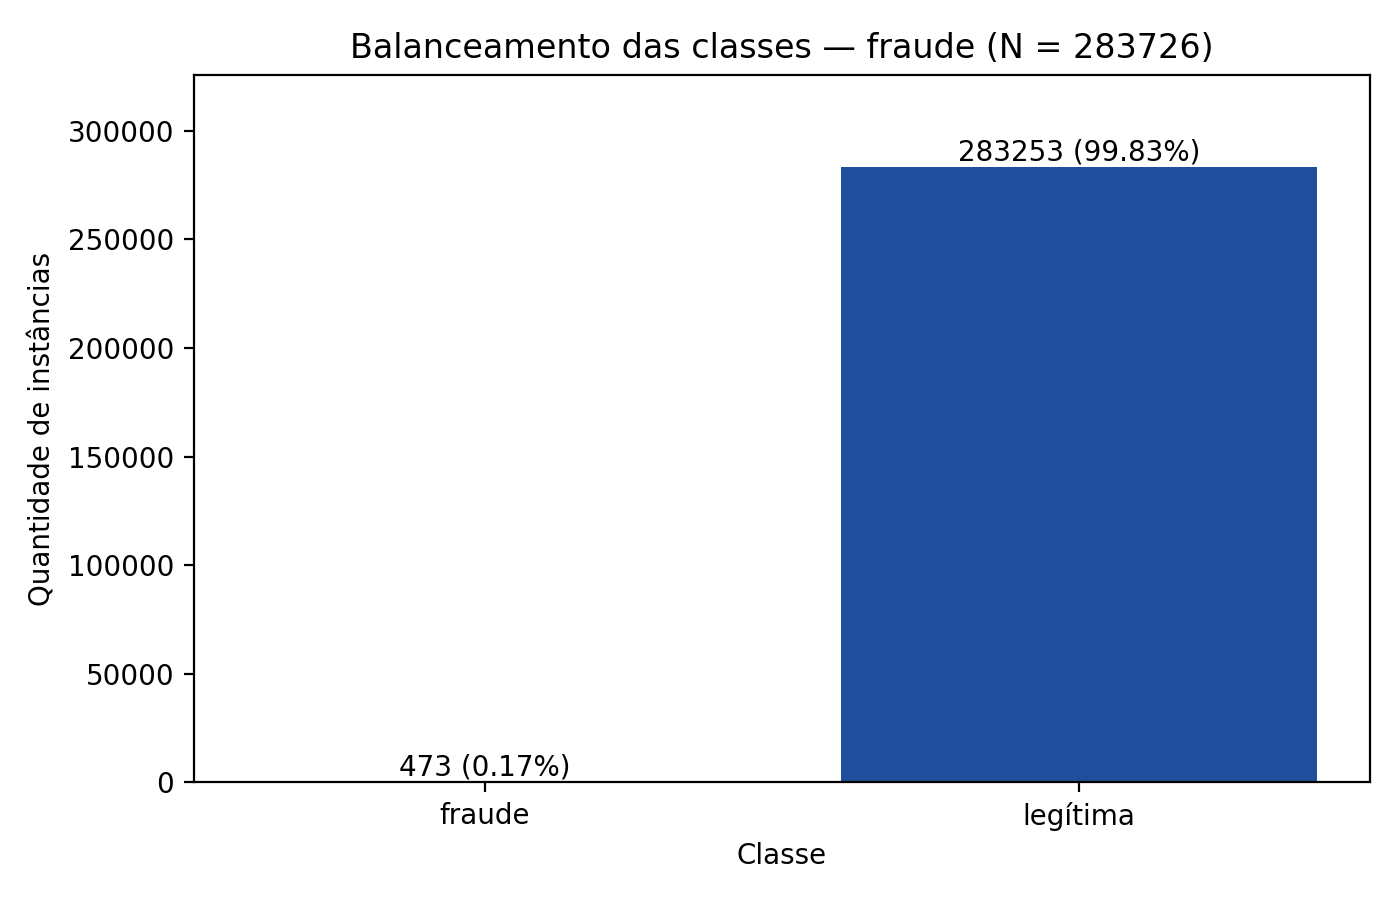

In [5]:
balanceamento = evaluate.class_balance_table(y, cfg)
table(balanceamento, "balanceamento")
show(evaluate.plot_class_balance(y, cfg, OUT / "01_balanceamento_classes.png",
                                 f"Balanceamento das classes — {DOMAIN} (N = {len(y)})"))

**Atenção:** desbalanceamento extremo (~0,17% de fraude). Um modelo que responde sempre "legítima" teria ~99,8% de acurácia, por isso a acurácia é enganosa neste domínio. No histograma da Parte 1, as barras vermelhas ficam muito pequenas porque o denominador é N (comportamento exigido).

## 3. Split estratificado 60/20/20 (treino / validação / teste)

In [6]:
with timed("split"):
    splits = pipeline.split_data(X, y)
X_tr, y_tr = splits["treino"]
X_val, y_val = splits["validacao"]
X_te, y_te = splits["teste"]
table(pipeline.split_table(splits), "split")

[tempo] split: 0.2 s


,conjunto,n,pct_do_total,n_positivos,pct_positivos,n_negativos
0,treino,170235,60.0,284,0.17,169951
1,validacao,56745,20.0,94,0.17,56651
2,teste,56746,20.0,95,0.17,56651


## 4. Tuning por validação cruzada (somente no treino)

Pipeline completo (pré-processamento + modelo) dentro da busca; `StratifiedKFold(n_splits=5, shuffle=True)`. Checkpoint em `models/`.

In [7]:
tuned = pipeline.tune_all(DOMAIN, X_tr, y_tr, force_retrain=FORCE_RETRAIN)
hiperparametros = pipeline.hyperparams_table(tuned, cfg["target_metric"])
table(hiperparametros, "hiperparametros")

[checkpoint] Regressão Logística: carregado de regressao_logistica.joblib
[tempo] tuning Regressão Logística: 0.0 s
[checkpoint] Random Forest: carregado de random_forest.joblib
[tempo] tuning Random Forest: 0.0 s
[checkpoint] Gradient Boosting (HGB): carregado de gradient_boosting__hgb.joblib
[tempo] tuning Gradient Boosting (HGB): 0.0 s


,modelo,metrica_cv,cv_average_precision_media,cv_average_precision_desvio,cv_folds,candidatos_testados,tempo_tuning_s,melhores_hiperparametros
0,Regressão Logística,average_precision,0.7384,0.0550,5,15,19.0334,C=0.984674
1,Random Forest,average_precision,0.8297,0.0726,5,15,2936.3837,n_estimators=100; min_samples_leaf=1; max_feat...
2,Gradient Boosting (HGB),average_precision,0.7486,0.0664,5,15,65.5414,l2_regularization=0; learning_rate=0.0305156; ...


## 5. Comparação dos modelos na validação (limiar = 0,5 nas métricas de decisão)

[tempo] avaliação na validação: 0.4 s


,modelo,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,0.5,0.9735,0.0539,0.9043,0.1017,0.9789,0.8106,0.7868,55159,1492,9,85
1,Random Forest,0.5,0.9996,0.9487,0.7872,0.8605,0.9512,0.8789,0.8735,56647,4,20,74
2,Gradient Boosting (HGB),0.5,0.9978,0.4154,0.8617,0.5606,0.9155,0.8258,0.8250,56537,114,13,81


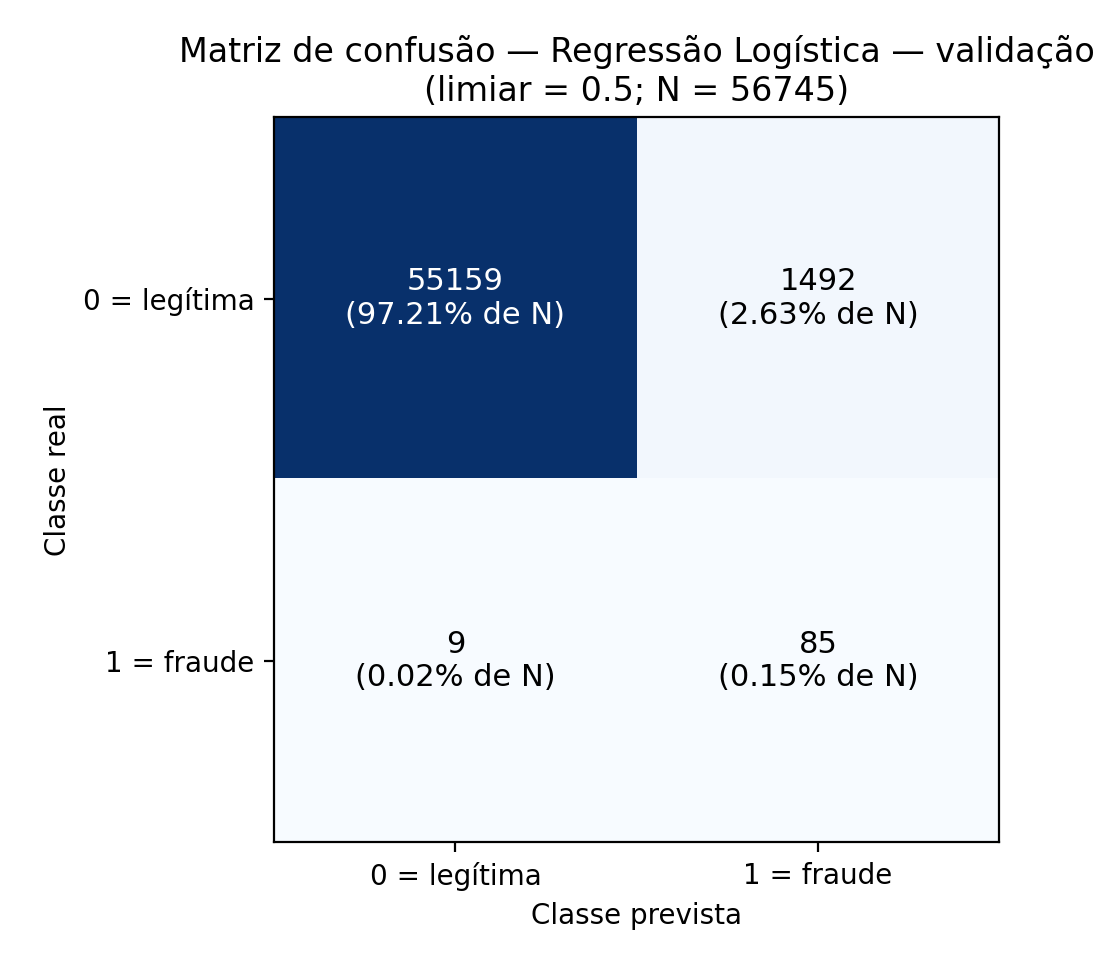

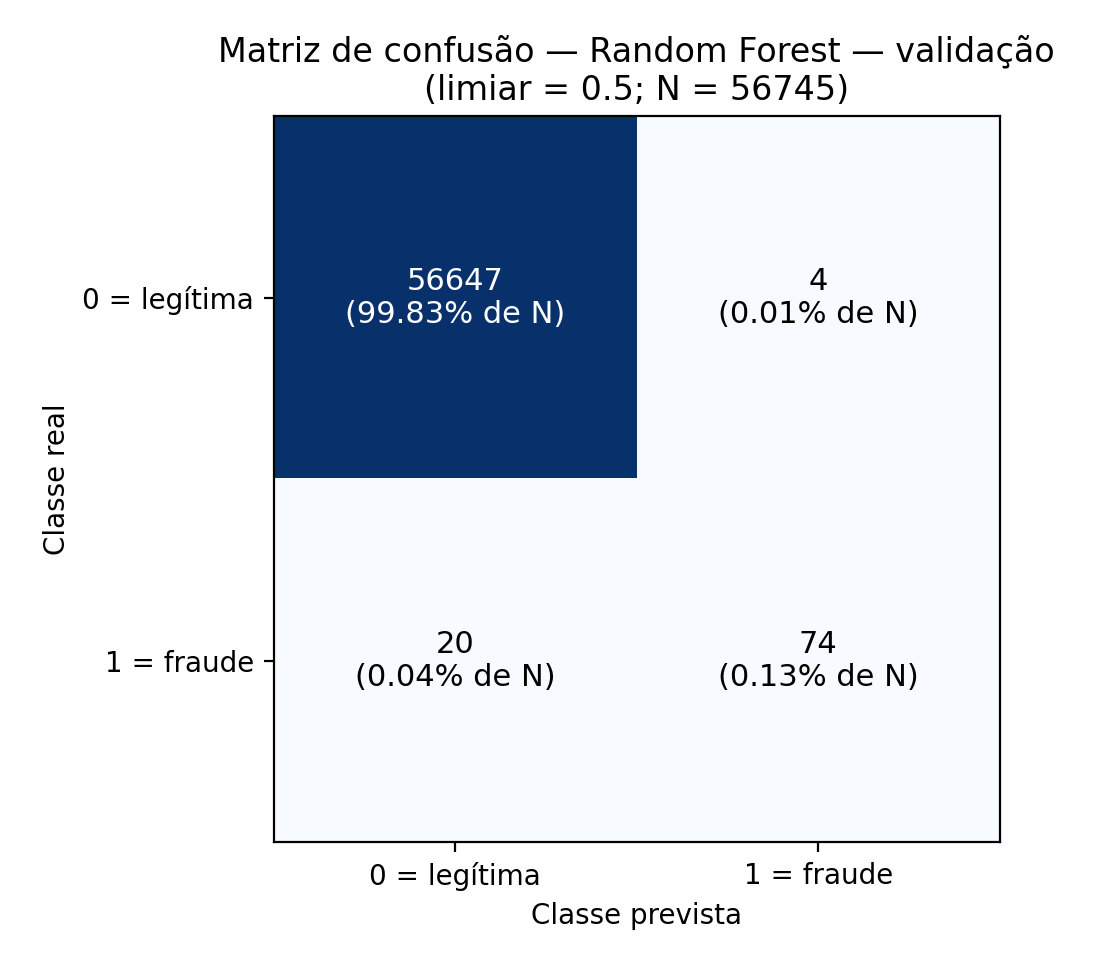

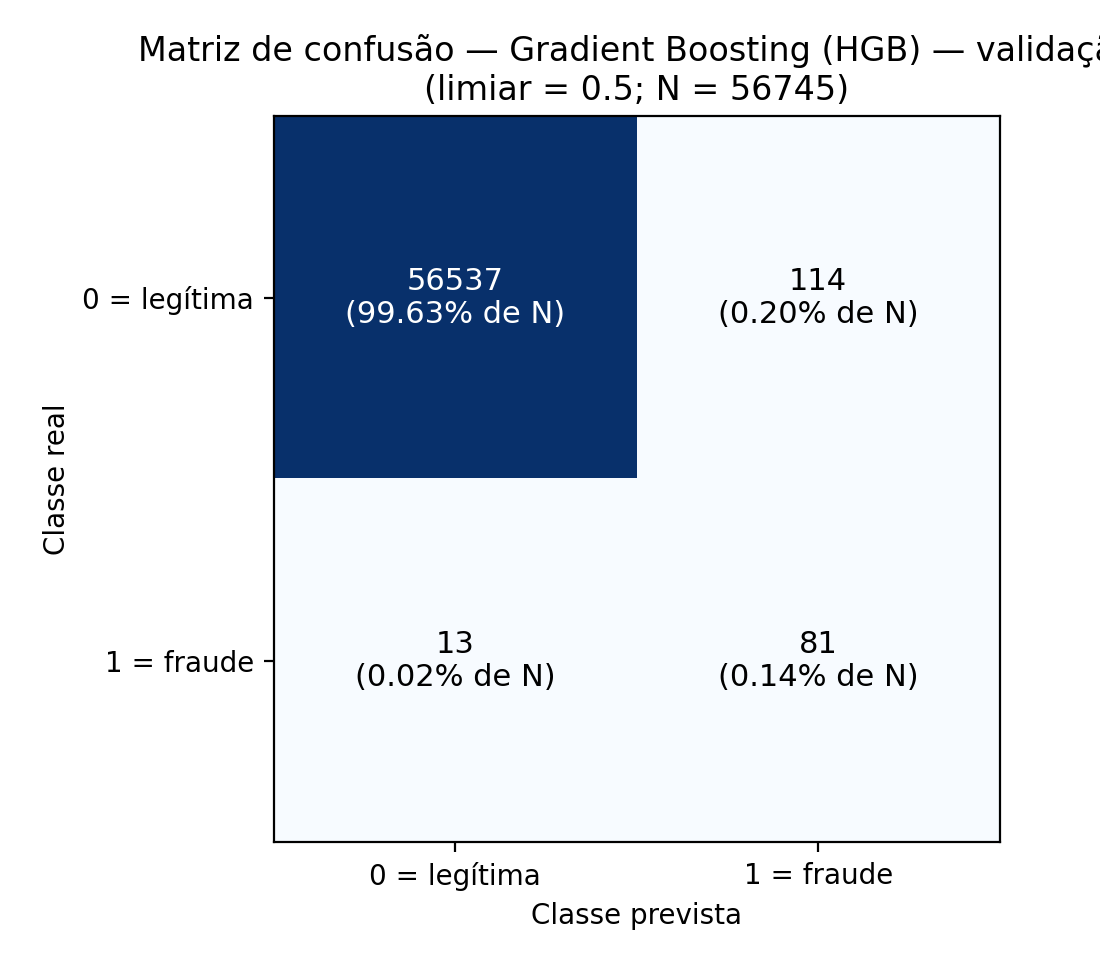

In [8]:
with timed("avaliação na validação"):
    val_probas = {name: pipeline.predict_positive(ck["estimator"], X_val)
                  for name, ck in tuned.items()}
    comparacao = evaluate.comparison_table(y_val, val_probas)
table(comparacao, "comparacao_validacao")
for name, p in val_probas.items():
    show(evaluate.plot_confusion(
        y_val, p, cfg, OUT / f"02_matriz_confusao_validacao_{pipeline.slug(name)}.png",
        f"Matriz de confusão — {name} — validação"))

## 6. Seleção do melhor modelo (métrica-alvo na validação)

In [9]:
best_name, best_col, best_value = evaluate.select_best(comparacao, cfg["target_metric"])
best = tuned[best_name]["estimator"]
selecao = f"{best_name} — maior {best_col} na validação = {best_value:.4f}"
print("Melhor modelo:", selecao)

Melhor modelo: Random Forest — maior average_precision_AP na validação = 0.8735


## 7. Curvas ROC e PR na validação

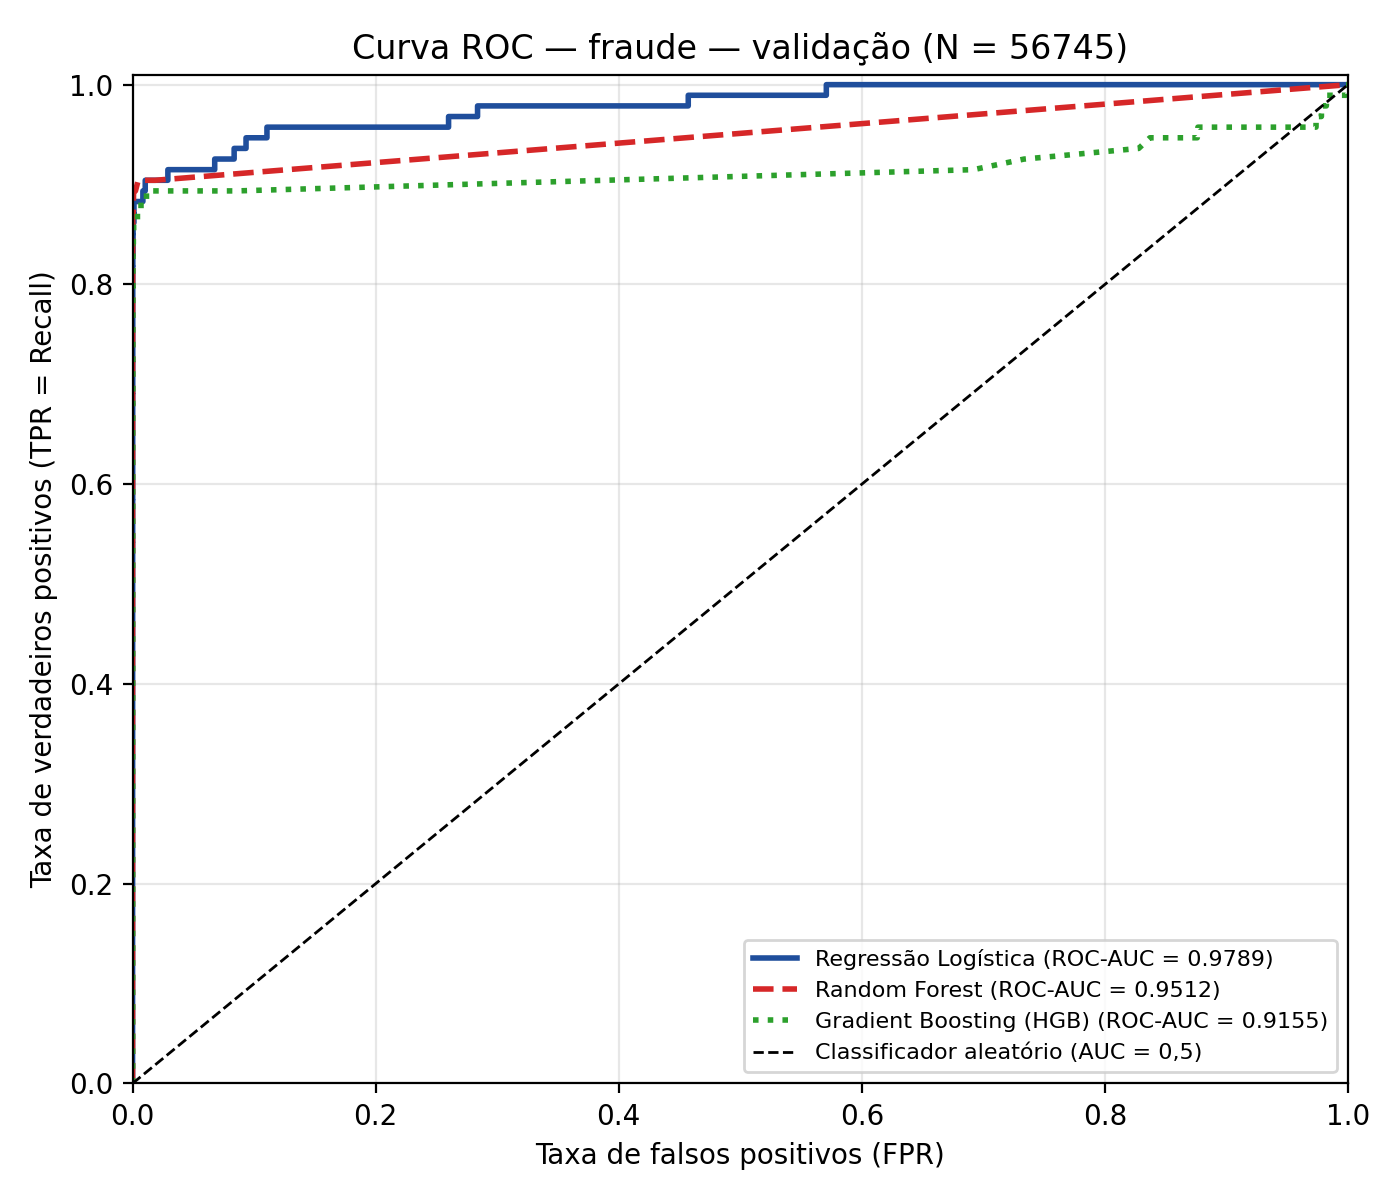

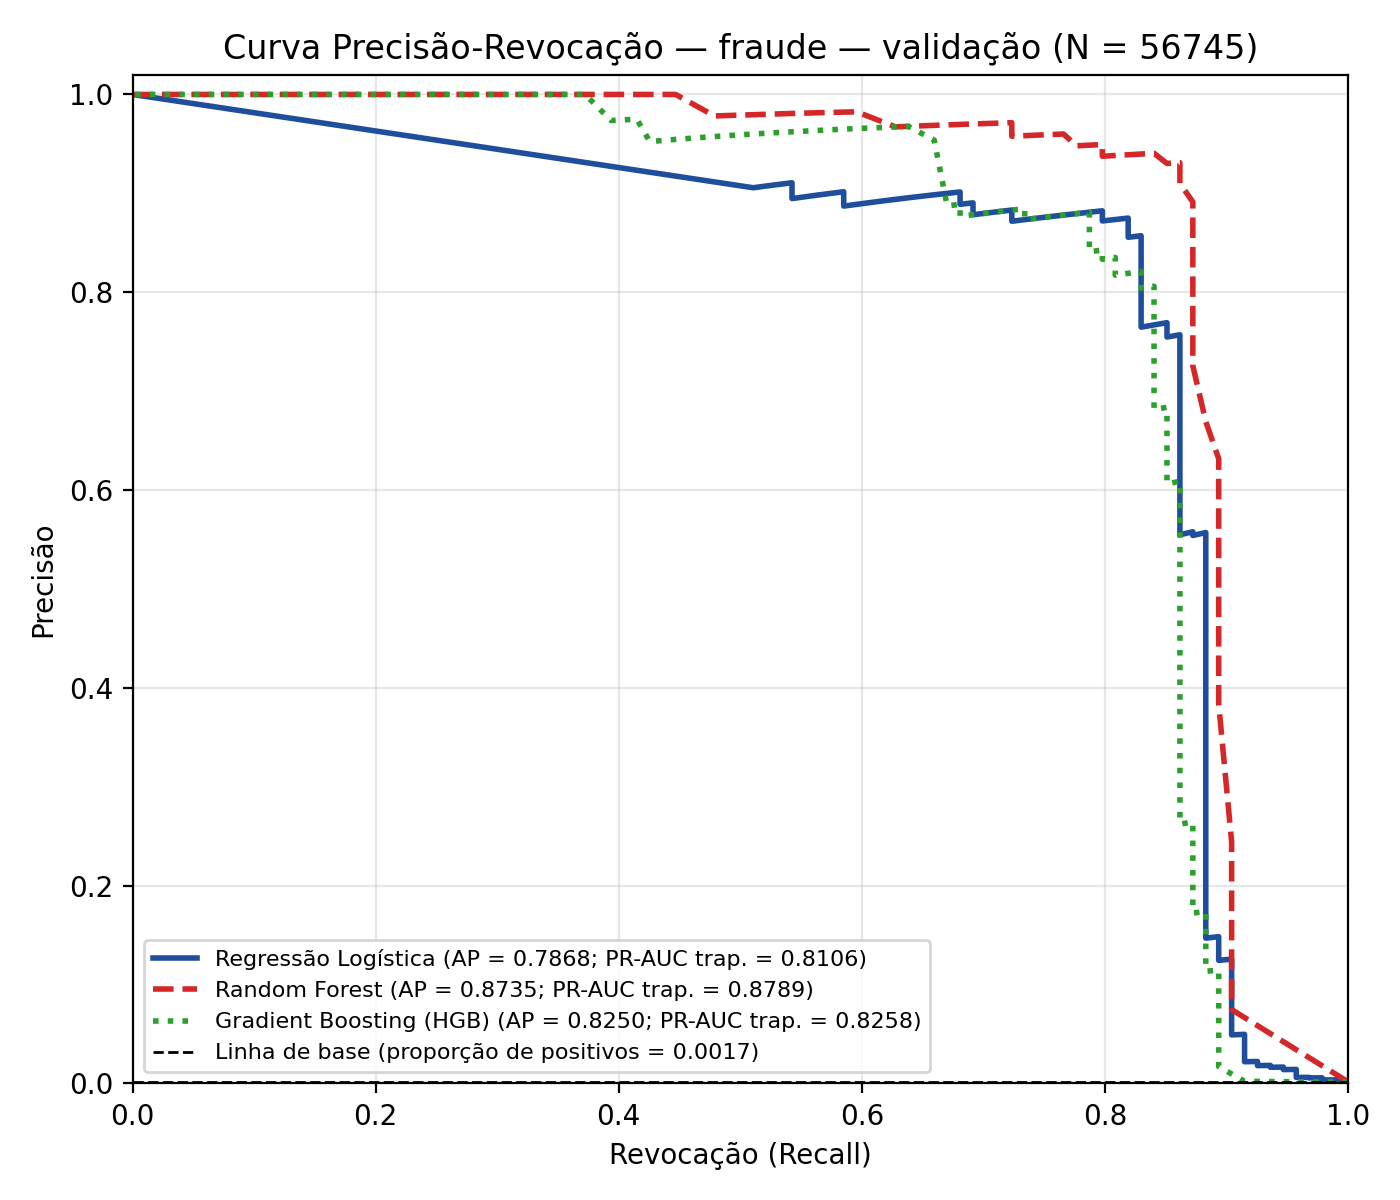

In [10]:
n_val = len(y_val)
show(evaluate.plot_roc(y_val, val_probas, OUT / "03_curva_roc_validacao.png",
                       f"Curva ROC — {DOMAIN} — validação (N = {n_val})"))
show(evaluate.plot_pr(y_val, val_probas, OUT / "04_curva_pr_validacao.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — validação (N = {n_val})"))

## 8. Varredura de limiar do melhor modelo (validação)

In [11]:
varredura = evaluate.threshold_sweep(y_val, val_probas[best_name])
table(varredura, "varredura_limiar")

,limiar,TP,FP,TN,FN,TPR_recall,FPR,precisao
0,0.1,82,21,56630,12,0.8723,0.0004,0.7961
1,0.2,81,8,56643,13,0.8617,0.0001,0.9101
2,0.3,79,5,56646,15,0.8404,0.0001,0.9405
3,0.4,78,5,56646,16,0.8298,0.0001,0.9398
4,0.5,74,4,56647,20,0.7872,0.0001,0.9487
5,0.6,71,3,56648,23,0.7553,0.0001,0.9595
6,0.7,65,2,56649,29,0.6915,0.0000,0.9701
7,0.8,56,1,56650,38,0.5957,0.0000,0.9825
8,0.9,34,0,56651,60,0.3617,0.0000,1.0000


## 9. Avaliação final no teste (melhor modelo, sem retreinar e sem ajustes)

[tempo] avaliação no teste: 0.2 s


,modelo,conjunto,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Random Forest,teste,0.5,0.9995,0.9571,0.7053,0.8121,0.9245,0.8113,0.8029,56648,3,28,67


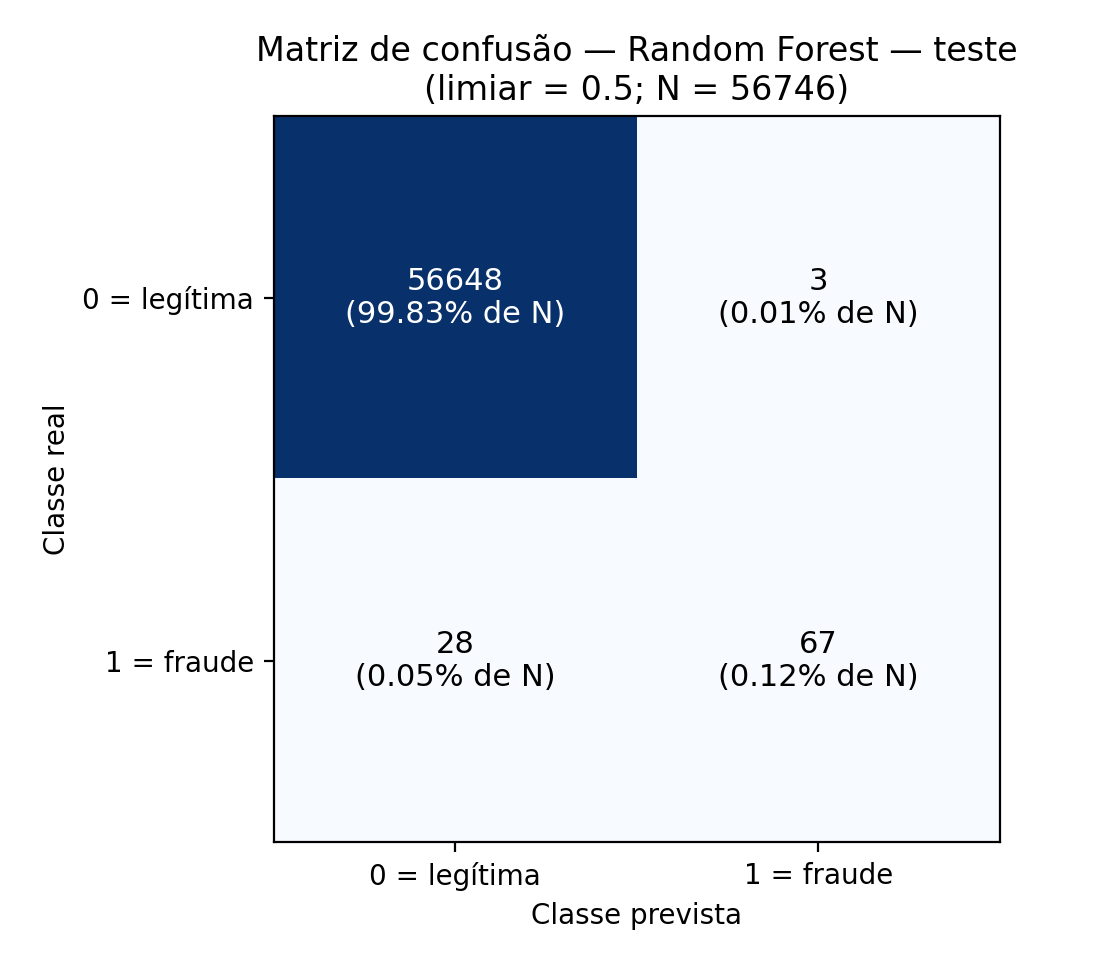

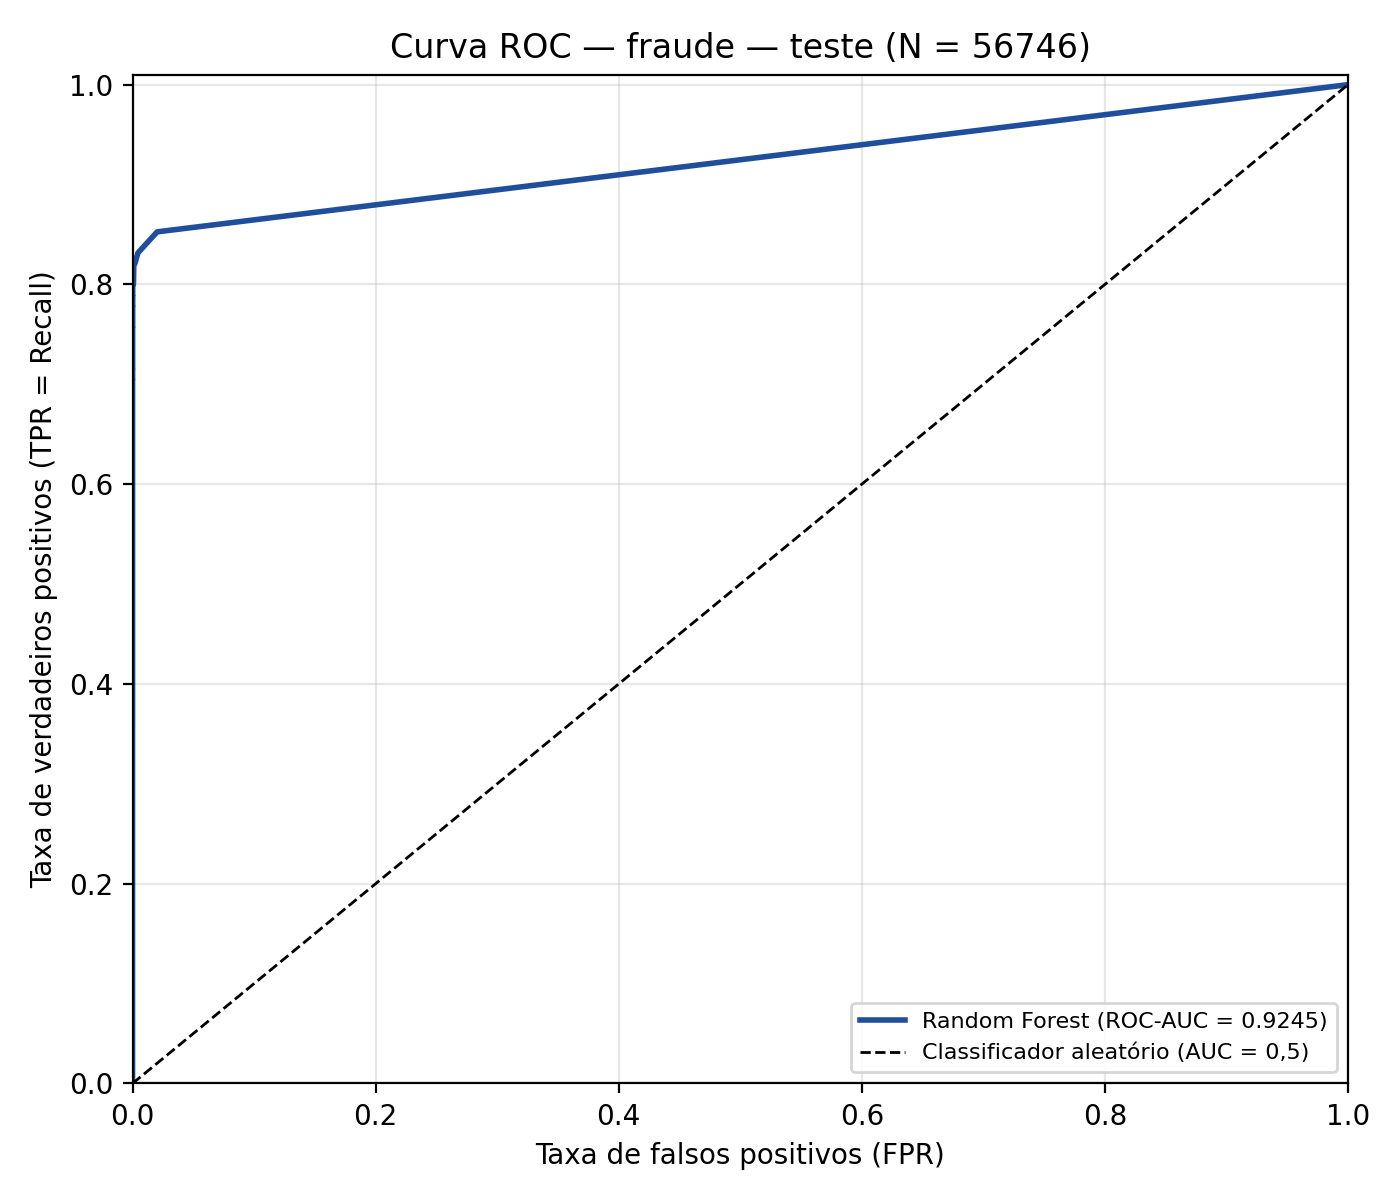

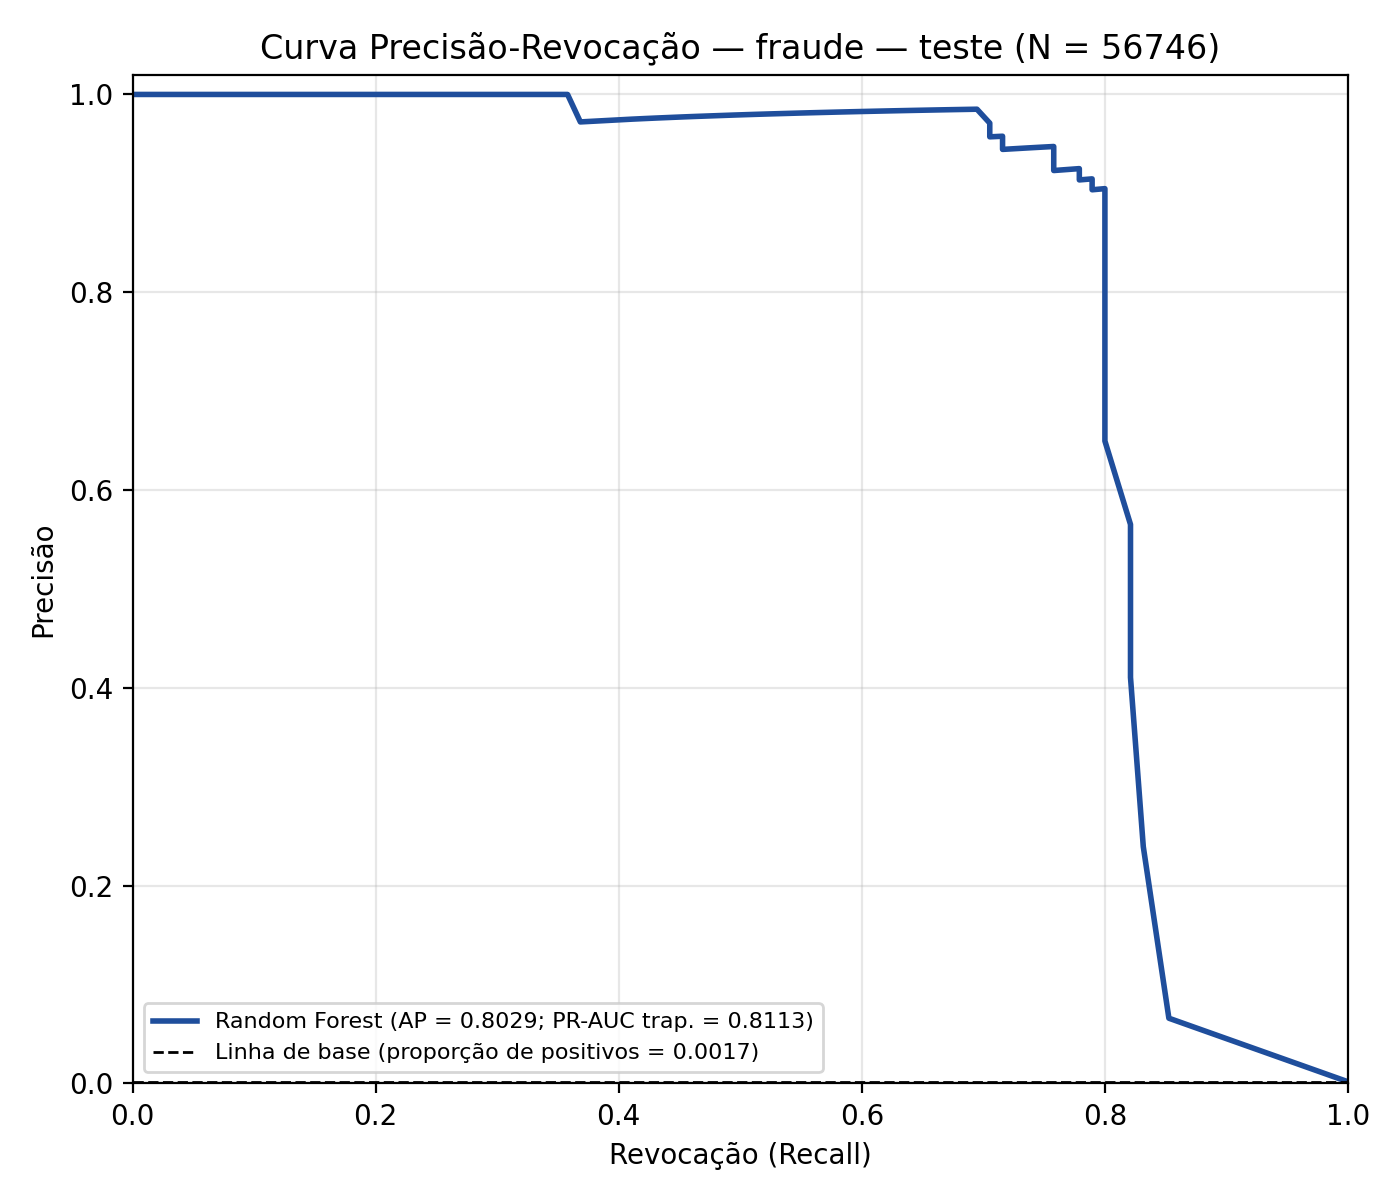

In [12]:
with timed("avaliação no teste"):
    p_test = pipeline.predict_positive(best, X_te)
    resultado_teste = evaluate.comparison_table(y_te, {best_name: p_test})
resultado_teste.insert(1, "conjunto", "teste")
table(resultado_teste, "resultado_teste")
n_te = len(y_te)
show(evaluate.plot_confusion(y_te, p_test, cfg, OUT / "05_matriz_confusao_teste.png",
                             f"Matriz de confusão — {best_name} — teste"))
show(evaluate.plot_roc(y_te, {best_name: p_test}, OUT / "06_curva_roc_teste.png",
                       f"Curva ROC — {DOMAIN} — teste (N = {n_te})"))
show(evaluate.plot_pr(y_te, {best_name: p_test}, OUT / "07_curva_pr_teste.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — teste (N = {n_te})"))

## 10. SHAP beeswarm do melhor modelo (amostra do teste)

[tempo] SHAP: 7.0 s


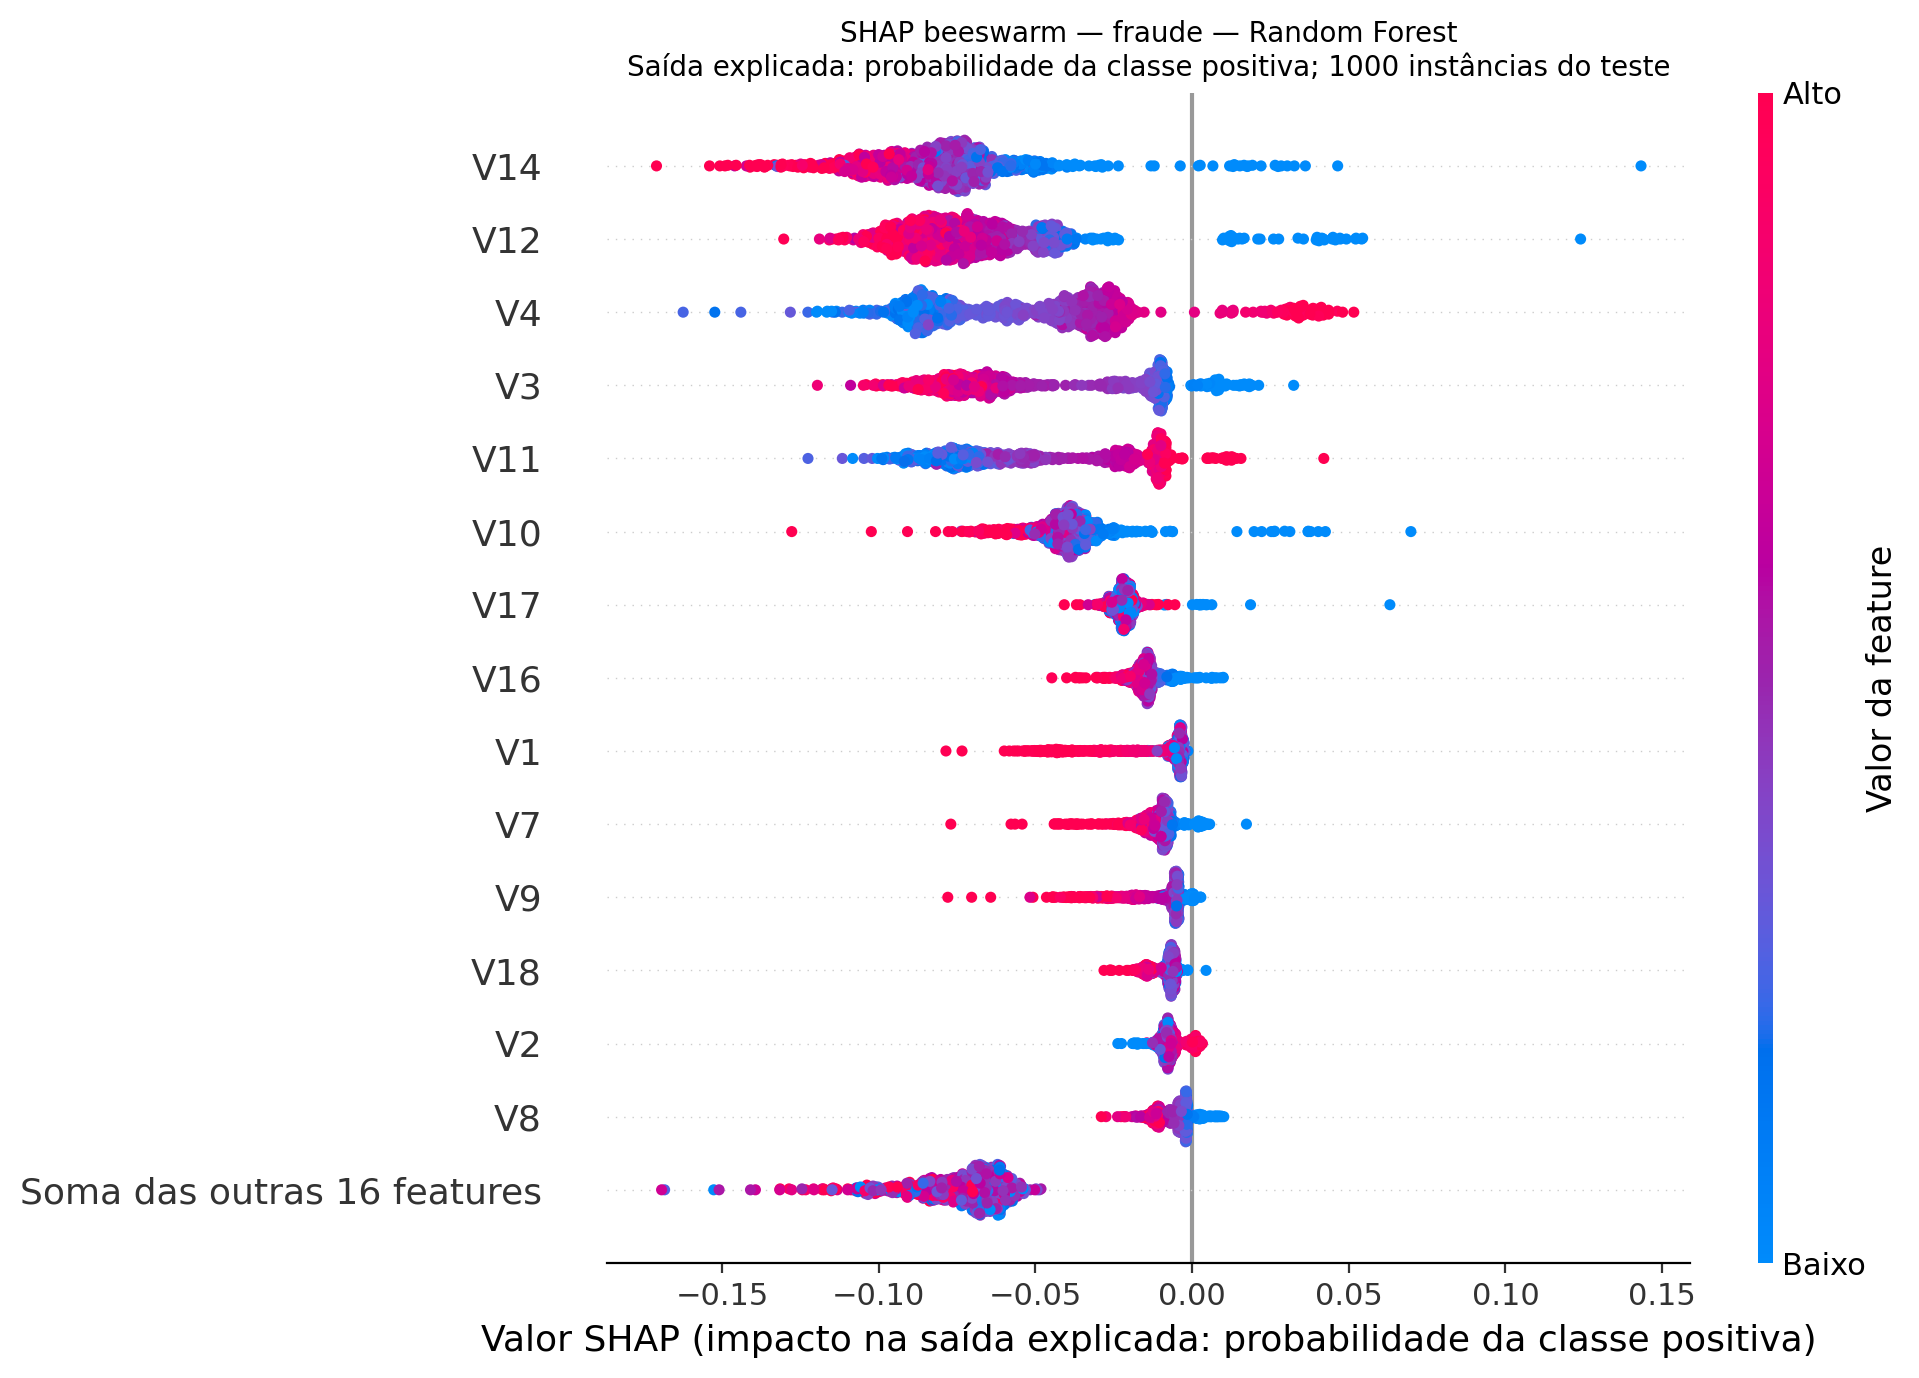

Domínio: fraude
Modelo explicado: Random Forest (RandomForestClassifier)
Explainer: TreeExplainer
Saída do modelo explicada: probabilidade da classe positiva (predict_proba[:, 1])
Dados explicados: 1000 instâncias aleatórias do conjunto de TESTE (random_state=42), transformadas pelo pré-processamento do pipeline
Conjunto de fundo (background): 100 instâncias aleatórias do TREINO
Número de features após o pré-processamento: 30
Beeswarm: max_display=15; cor = valor da feature (vermelho alto, azul baixo); eixo X = contribuição SHAP para a saída explicada
Limitação: V1–V28 são componentes PCA anônimos fornecidos pela base; não têm significado de negócio interpretável. Apenas Time e Amount são variáveis originais.


,posicao,feature,media_abs_shap,correlacao_valor_shap,leitura
0,1,V14,0.0818,-0.9010,valores altos diminuem a saída
1,2,V12,0.0712,-0.9150,valores altos diminuem a saída
2,3,V4,0.0550,0.9284,valores altos aumentam a saída
3,4,V3,0.0490,-0.9025,valores altos diminuem a saída
4,5,V11,0.0470,0.9290,valores altos aumentam a saída
5,6,V10,0.0408,-0.7900,valores altos diminuem a saída
6,7,V17,0.0218,-0.3187,valores altos diminuem a saída
7,8,V16,0.0148,-0.8619,valores altos diminuem a saída
8,9,V1,0.0130,-0.6065,valores altos diminuem a saída
9,10,V7,0.0117,-0.8472,valores altos diminuem a saída


In [13]:
with timed("SHAP"):
    shap_res = explain.explain_model(DOMAIN, best_name, best, X_tr, X_te, OUT,
                                     OUT / "08_shap_beeswarm.png")
show(OUT / "08_shap_beeswarm.png")
print("\n".join(shap_res["info"]))
display(evaluate.round_table(shap_res["top10"]))

## 11. Parte 1 aplicada ao melhor modelo

Cortes escolhidos **somente na validação** e aplicados ao teste **sem ajuste**.

t1 = 0.02 | t2 = 0.16  (max_fn_rate = 0.1 sobre positivos, max_fp_rate = 0.0002 sobre negativos)


,t1,t2,volume_manual,cobertura_automatica,fn_auto,fn_auto_sobre_positivos,fp_auto,fp_auto_sobre_negativos,violacao,viavel
0,0.02,0.16,0.0045,0.9955,9,0.0957,10,0.0002,0.0,True
1,0.02,0.17,0.0046,0.9954,9,0.0957,8,0.0001,0.0,True
2,0.02,0.18,0.0046,0.9954,9,0.0957,8,0.0001,0.0,True
3,0.02,0.19,0.0046,0.9954,9,0.0957,8,0.0001,0.0,True
4,0.02,0.20,0.0046,0.9954,9,0.0957,8,0.0001,0.0,True
5,0.02,0.21,0.0046,0.9954,9,0.0957,7,0.0001,0.0,True
6,0.02,0.22,0.0046,0.9954,9,0.0957,6,0.0001,0.0,True
7,0.02,0.23,0.0046,0.9954,9,0.0957,6,0.0001,0.0,True
8,0.02,0.24,0.0046,0.9954,9,0.0957,6,0.0001,0.0,True
9,0.02,0.25,0.0046,0.9954,9,0.0957,6,0.0001,0.0,True


,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,56397,99.39,9,0.02,56388,99.98
1,Análise manual,t1 ≤ p < t2,256,0.45,3,1.17,253,98.83
2,Positiva automática,p ≥ t2,92,0.16,82,89.13,10,10.87
3,Total,"t1 = 0.02, t2 = 0.16",56745,100.00,94,0.17,56651,99.83


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,9.0000,NaN,9,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0957,9.57,9,94,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0002,0.02,9,56745,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,10.0000,NaN,10,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0002,0.02,10,56651,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0002,0.02,10,56745,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9955,99.55,56489,56745,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0045,0.45,256,56745,N (total de instâncias),proporção de N encaminhada à análise manual


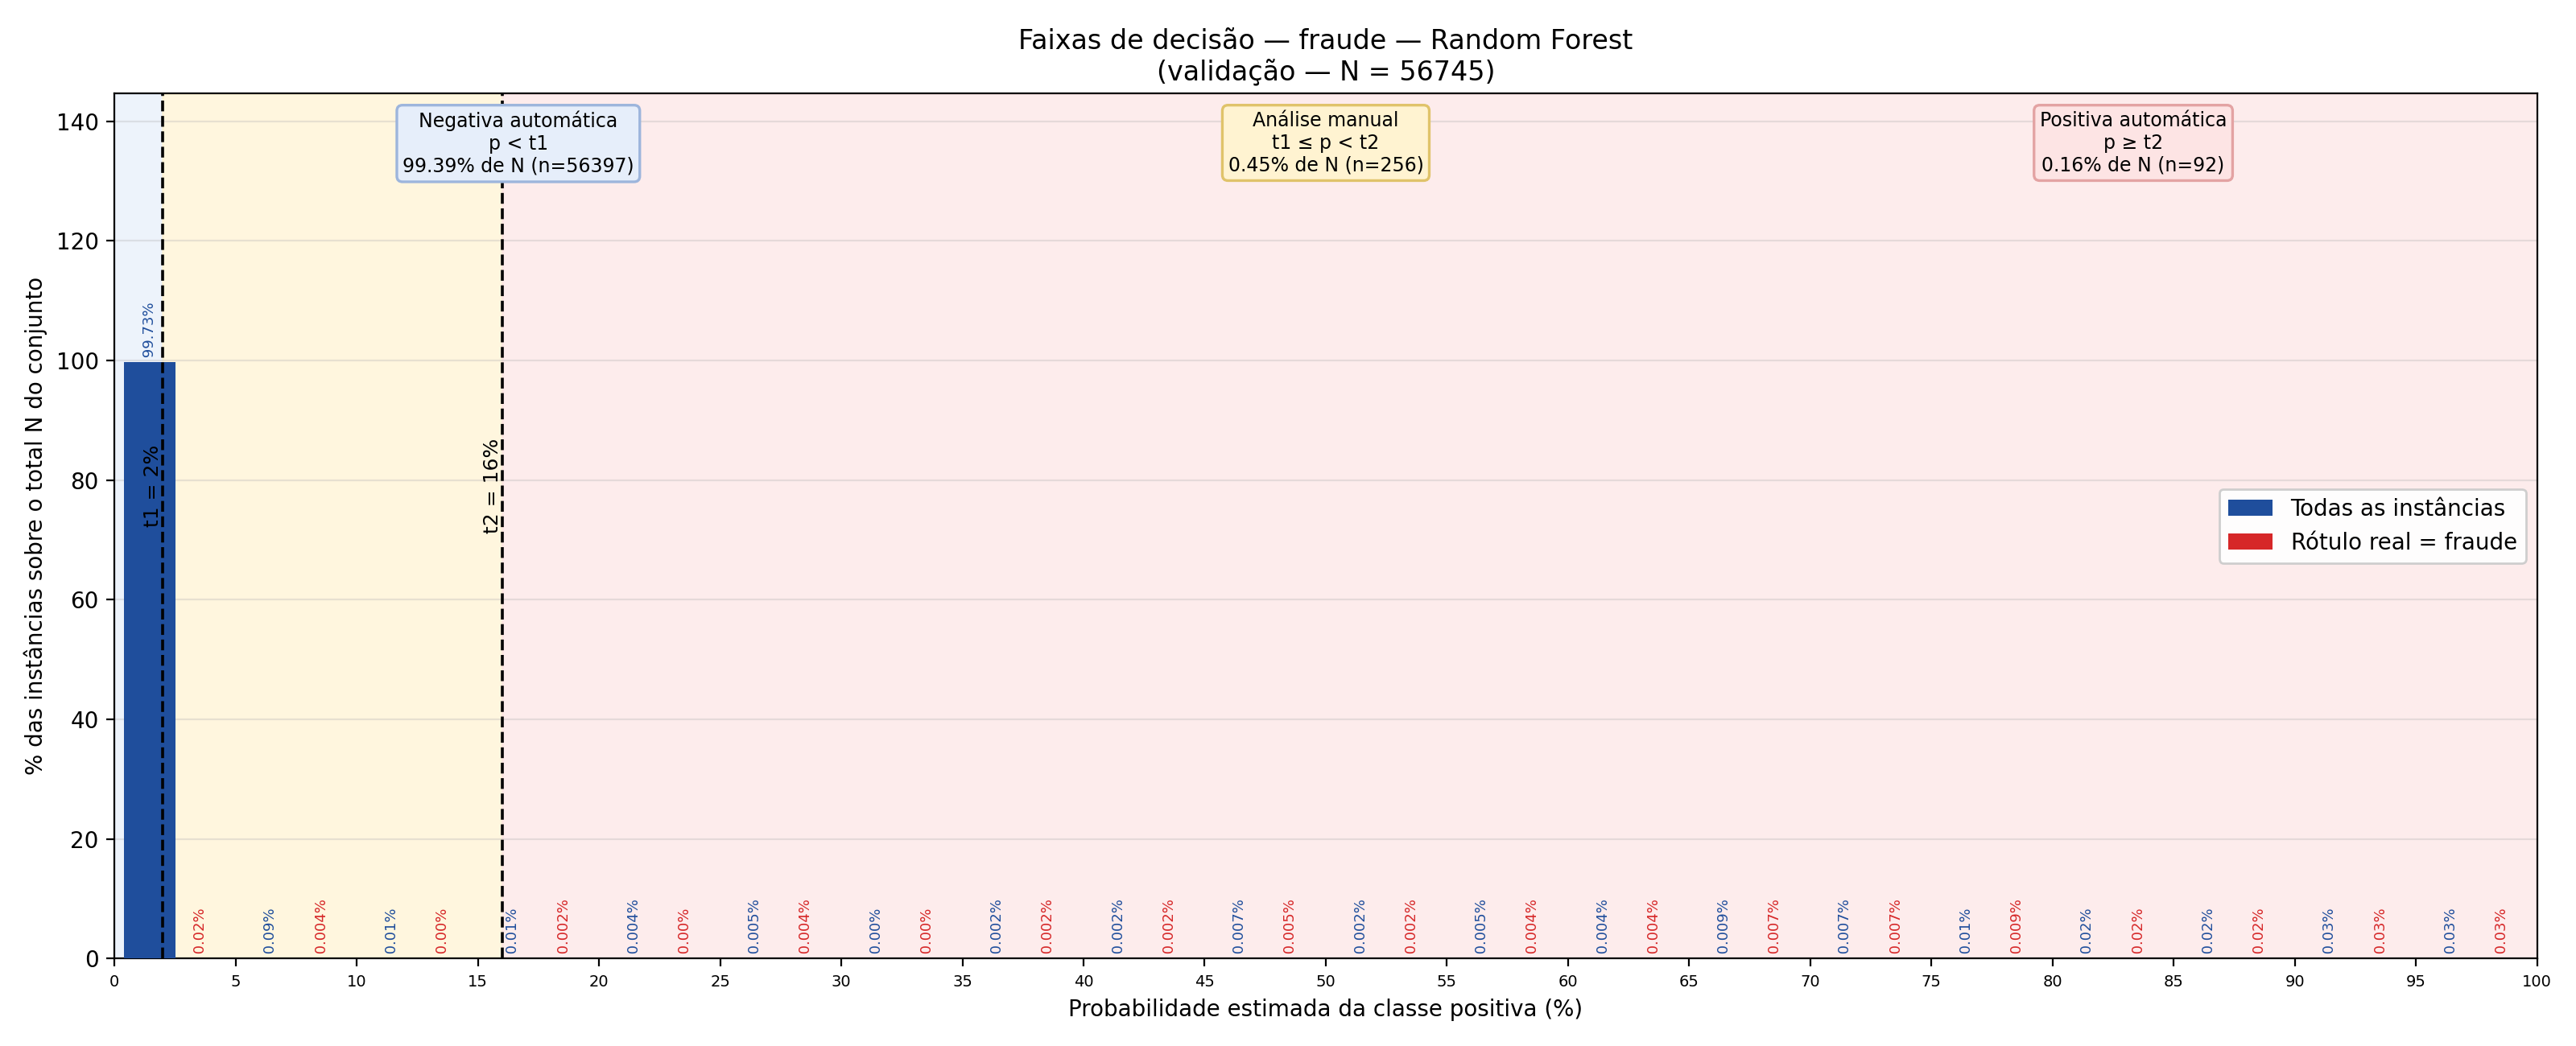

In [14]:
p_val = val_probas[best_name]
(t1, t2), rep_val, tradeoff = cutoff_hist.choose_cutoffs(
    y_val, p_val, cfg["max_fn_rate"], cfg["max_fp_rate"])
print(f"t1 = {t1:.2f} | t2 = {t2:.2f}  (max_fn_rate = {cfg['max_fn_rate']} sobre positivos, "
      f"max_fp_rate = {cfg['max_fp_rate']} sobre negativos)")
table(tradeoff, "faixas/tradeoff_validacao")
table(rep_val["faixas"], "faixas/band_report_validacao_faixas")
table(rep_val["erros"], "faixas/band_report_validacao_erros")
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_val, p_val, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "09_histograma_faixas_validacao.png",
    dataset_name="validação")
plt.close(fig)
show(FX / "09_histograma_faixas_validacao.png")

,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,56416,99.42,16,0.03,56400,99.97
1,Análise manual,t1 ≤ p < t2,247,0.44,4,1.62,243,98.38
2,Positiva automática,p ≥ t2,83,0.15,75,90.36,8,9.64
3,Total,"t1 = 0.02, t2 = 0.16",56746,100.00,95,0.17,56651,99.83


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,16.0000,NaN,16,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.1684,16.84,16,95,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0003,0.03,16,56746,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,8.0000,NaN,8,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0001,0.01,8,56651,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0001,0.01,8,56746,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9956,99.56,56499,56746,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0044,0.44,247,56746,N (total de instâncias),proporção de N encaminhada à análise manual


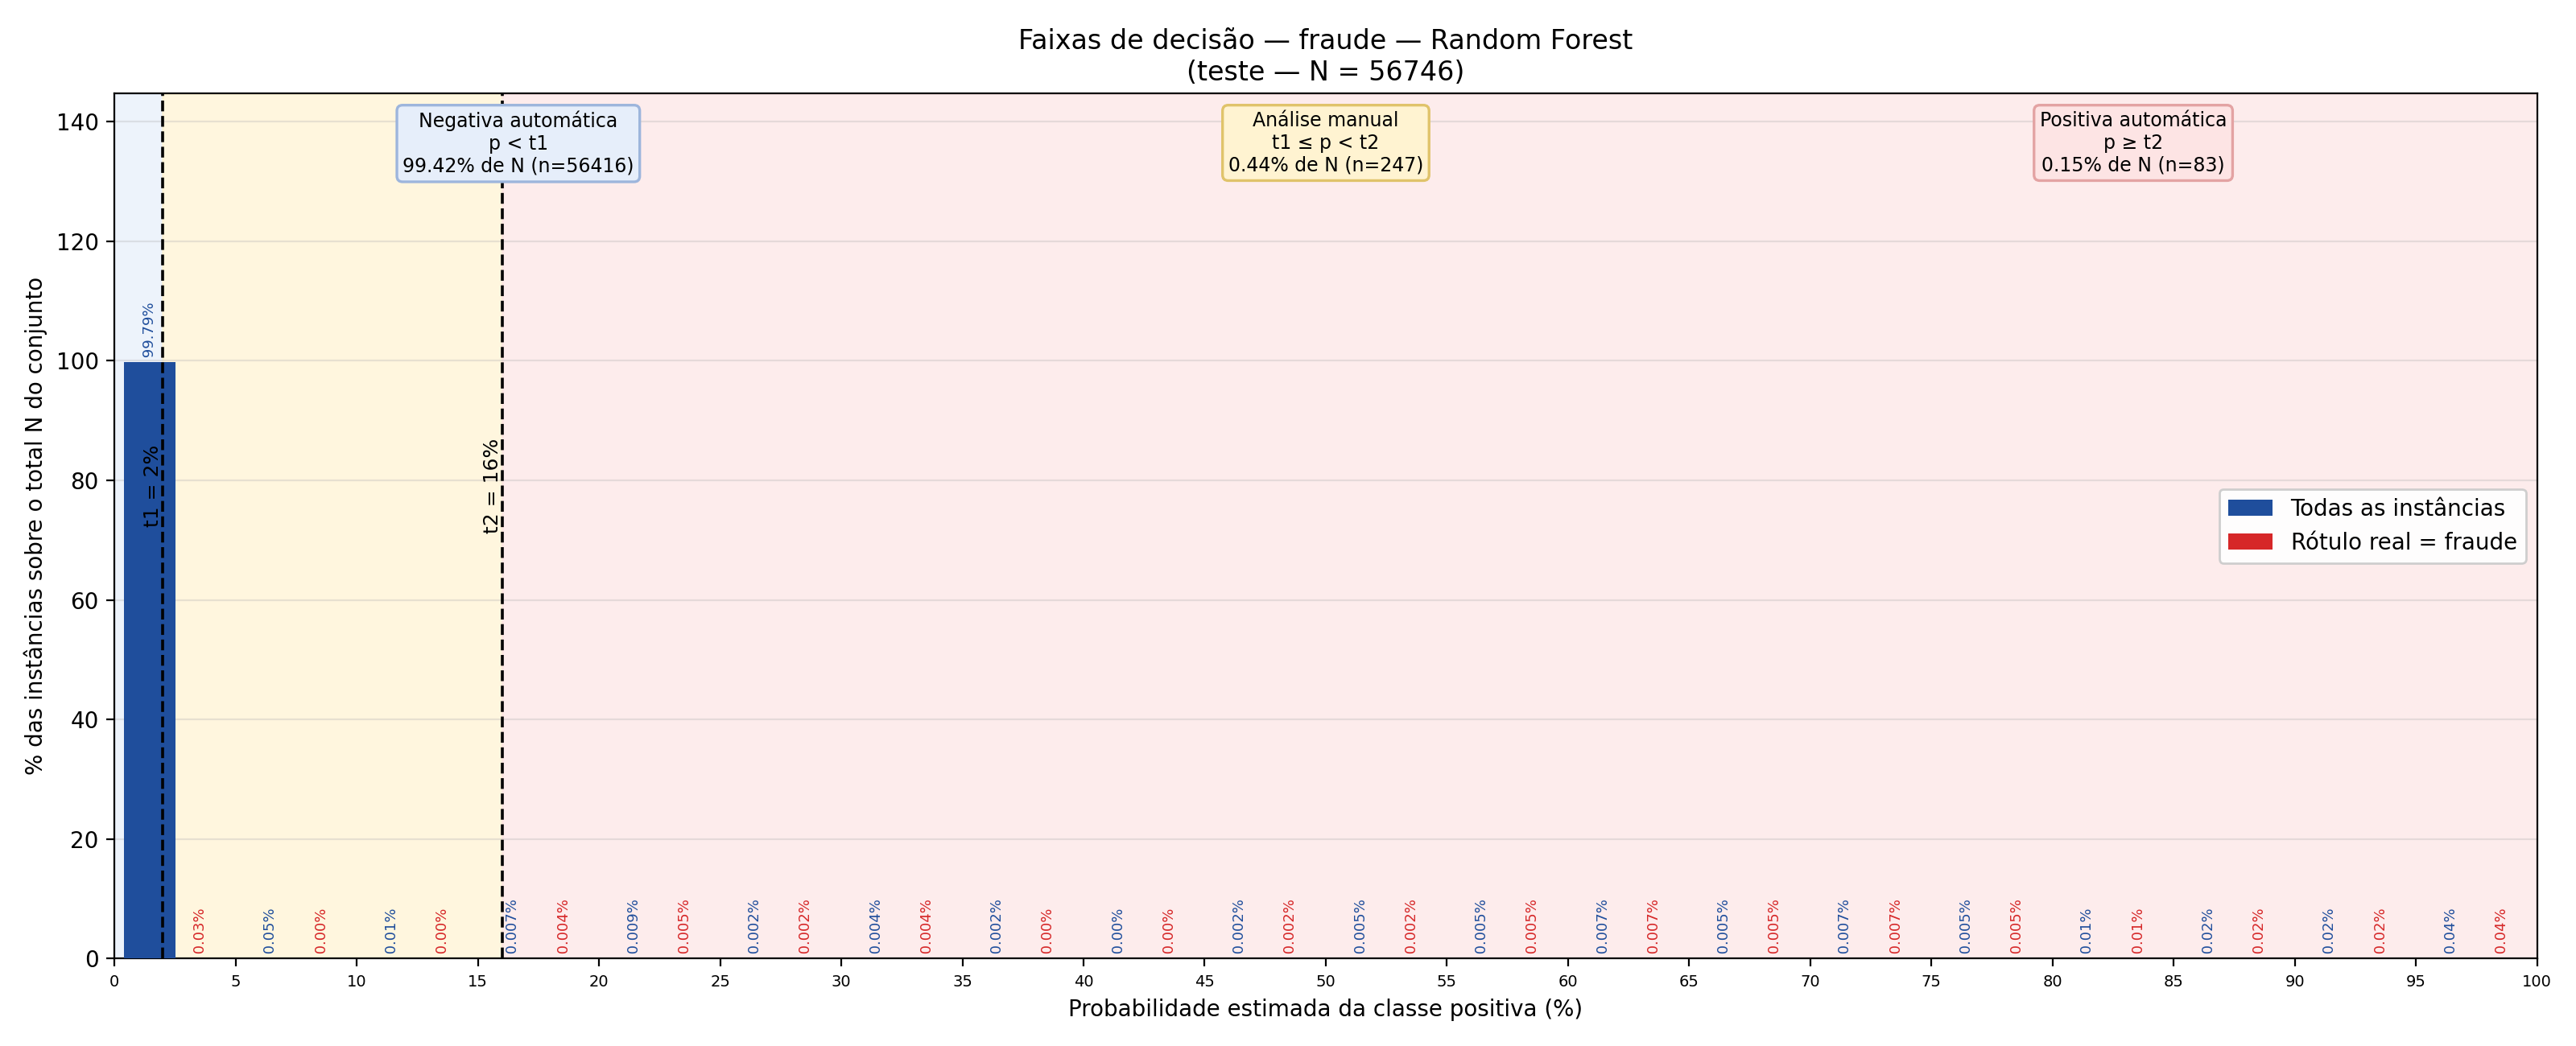

In [15]:
rep_test = cutoff_hist.band_report(y_te, p_test, t1, t2)   # mesmos t1 e t2 da validação
table(rep_test["faixas"], "faixas/band_report_teste_faixas")
table(rep_test["erros"], "faixas/band_report_teste_erros")
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_te, p_test, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "10_histograma_faixas_teste.png",
    dataset_name="teste")
plt.close(fig)
show(FX / "10_histograma_faixas_teste.png")
pd.DataFrame({"y_true": y_val, "y_proba": p_val}).to_csv(OUT / "preds_validacao.csv", index=False)
pd.DataFrame({"y_true": y_te, "y_proba": p_test}).to_csv(OUT / "preds_teste.csv", index=False)

## 12. Resumo numérico

In [16]:
tempos = pd.DataFrame({"etapa": list(pipeline.TIMINGS), "segundos": list(pipeline.TIMINGS.values())})
blocos = [
    ("Balanceamento", balanceamento),
    ("Split 60/20/20", pipeline.split_table(splits)),
    (f"Hiperparâmetros vencedores (CV {config.CV_SPLITS} folds, {cfg['target_metric']})",
     hiperparametros),
    (f"Comparação na validação (limiar = {T})", comparacao),
    ("Melhor modelo", selecao),
    (f"Resultado no teste (limiar = {T})", resultado_teste),
    ("SHAP — informações", shap_res["info"]),
    ("SHAP — top 10 features (média |SHAP|)", shap_res["top10"]),
    ("Cortes (escolhidos na validação)",
     [f"t1 = {t1:.2f}", f"t2 = {t2:.2f}",
      f"max_fn_rate = {cfg['max_fn_rate']} (sobre positivos)",
      f"max_fp_rate = {cfg['max_fp_rate']} (sobre negativos)"]),
    ("Trade-off (10 melhores pares viáveis, validação)", tradeoff),
    ("band_report — validação — faixas", rep_val["faixas"]),
    ("band_report — validação — erros", rep_val["erros"].drop(columns="descricao")),
    ("band_report — teste — faixas", rep_test["faixas"]),
    ("band_report — teste — erros", rep_test["erros"].drop(columns="descricao")),
    ("Tempo de execução (s)", tempos),
    ("Figuras geradas", FIGS),
]
resumo = evaluate.write_summary(OUT / "resumo_resultados.md",
                                f"Resumo de resultados — {DOMAIN}", blocos)
print("Resumo salvo em", resumo)

Resumo salvo em C:\Users\otavi\OneDrive\Desktop\data science\a2\outputs\fraude\resumo_resultados.md
